In [1]:
# Import Python Packages
import pandas as pd
import numpy as np
import plotly.express as px
import warnings 
warnings.filterwarnings('ignore')

In [9]:
country_coordinates = pd.read_csv("world_country_coordinates.csv")
dataset = pd.read_csv("global_covid19_mortality_rates.csv")

In [15]:
country_coordinates = country_coordinates.drop(columns=['usa_state_code', 'usa_state_latitude', 'usa_state_longitude', 'usa_state'])
country_coordinates.sample(10)



,country_code,latitude,longitude,country
119,KR,35.907757,127.766922,South Korea
131,LU,49.815273,6.129583,Luxembourg
81,GM,13.443182,-15.310139,Gambia
62,EH,24.215527,-12.885834,Western Sahara
233,VG,18.420695,-64.639968,British Virgin Islands
205,SV,13.794185,-88.896530,El Salvador
105,IR,32.427908,53.688046,Iran
174,PK,30.375321,69.345116,Pakistan
141,ML,17.570692,-3.996166,Mali
124,LB,33.854721,35.862285,Lebanon


In [19]:
dataset.sample(5)

,Unnamed: 0,Country,Confirmed,Deaths,Mortality Ratio,Latitude,Longitude,Country_Code
74,74,Iran,432798.0,24840.0,5.74,32.427908,53.688046,IR
65,65,Guinea-Bissau,2324.0,39.0,1.68,11.803749,-15.180413,GW
170,170,Venezuela,69439.0,574.0,0.83,6.423750,-66.589730,VE
140,140,Seychelles,143.0,0.0,0.00,-4.679574,55.491977,SC
62,62,Grenada,24.0,0.0,0.00,12.262776,-61.604171,GD


In [25]:
dataset_deaths = pd.DataFrame(dataset.groupby('Country')['Deaths'].sum())
dataset_confirmed = pd.DataFrame(dataset.groupby('Country')['Confirmed'].sum())
dataset_confirmed['Deaths'] = dataset_deaths['Deaths']
dataset_global = dataset_confirmed
dataset_global['Mortality Ratio'] = np.round((dataset_global.Deaths.values/dataset_global.Confirmed.values)*100,2)
dataset_global = dataset_global.reset_index()
dataset_global = dataset_global.merge(country_coordinates, left_on='Country', right_on='country')
dataset_global = dataset_global[['Country','Confirmed','Deaths','Mortality Ratio','latitude','longitude','country_code']]
dataset_global.columns = ['Country','Confirmed','Deaths','Mortality Ratio','Latitude','Longitude','Country_Code']
dataset_global.to_csv('global_covid19_mortality.csv')

In [27]:
dataset_global.head()

,Country,Confirmed,Deaths,Mortality Ratio,Latitude,Longitude,Country_Code
0,Afghanistan,39145.0,1446.0,3.69,33.939110,67.709953,AF
1,Albania,12787.0,370.0,2.89,41.153332,20.168331,AL
2,Algeria,50400.0,1698.0,3.37,28.033886,1.659626,DZ
3,Andorra,1753.0,53.0,3.02,42.546245,1.601554,AD
4,Angola,4363.0,159.0,3.64,-11.202692,17.873887,AO


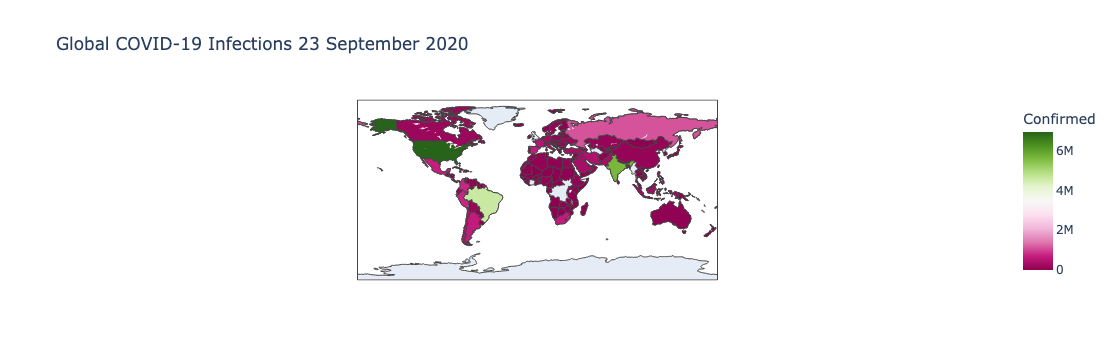

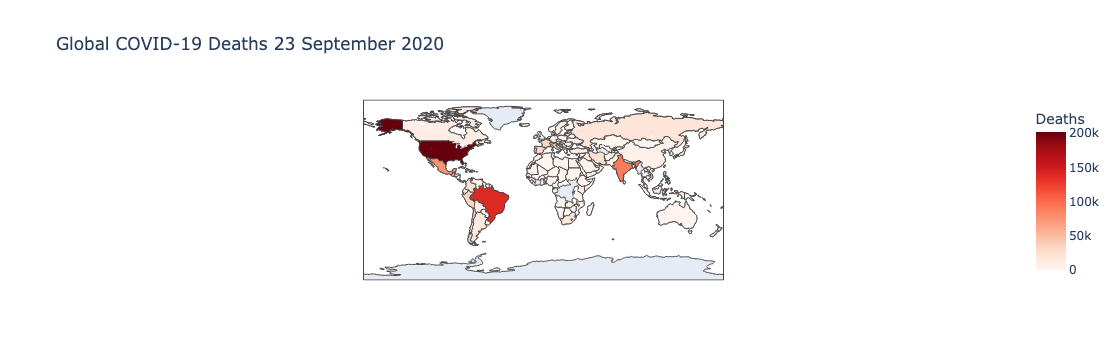

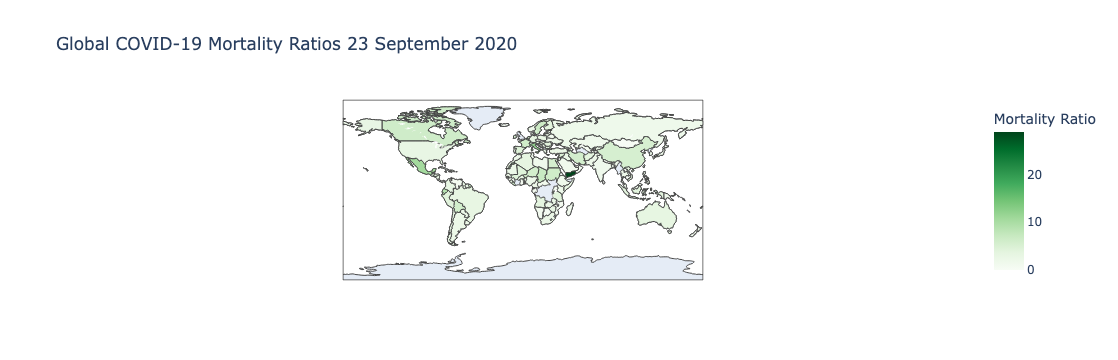

In [61]:
fig = px.choropleth(dataset_global, 
                    locations="Country", 
                    color="Confirmed", 
                    locationmode = 'country names', 
                    hover_name="Country",
                    color_continuous_scale='PiYG',
                    title='Global COVID-19 Infections 23 September 2020')
fig.write_image('Global COVID-19 Infection.png')
fig.show()

fig = px.choropleth(dataset_global, 
                    locations="Country", 
                    color="Deaths", 
                    locationmode = 'country names', 
                    hover_name="Country",
                    color_continuous_scale='reds',
                    title='Global COVID-19 Deaths 23 September 2020')
fig.write_image('Global COVID-19 Deaths.png') 
fig.show()

fig = px.choropleth(dataset_global, 
                    locations="Country", 
                    color="Mortality Ratio", 
                    locationmode = 'country names', 
                    hover_name="Country",
                    color_continuous_scale='gree',
                    title='Global COVID-19 Mortality Ratios 23 September 2020')
fig.write_image('Global COVID-19 Mortality Ratios.png') 
fig.show()

In [75]:
!pip install mgwr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 240.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 1.2 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 644.4 kB/s eta 0:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 1.0 MB/s eta 0:00:0000:01:00:01


In [85]:
# 1. Import libraries
import geopandas as gpd
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import matplotlib.pyplot as plt


# 3. Convert to GeoDataFrame using Latitude/Longitude
gdf = gpd.GeoDataFrame(dataset_global, geometry=gpd.points_from_xy(dataset_global.Longitude, dataset_global.Latitude))

# 4. Dependent variable (y) - Mortality Ratio
y = gdf['Mortality Ratio'].values.reshape((-1,1))

# 5. Independent variable(s) (X)
# Example: using Confirmed cases as predictor
X = gdf[['Confirmed']].values

# 6. Coordinates (for GWR)
coords = np.column_stack([gdf.geometry.x.values, gdf.geometry.y.values])

# 7. Select optimal bandwidth
selector = Sel_BW(coords, y, X)
bandwidth = selector.search(bw_min=2)
print("Optimal bandwidth:", bandwidth)

# 8. Fit GWR model
model = GWR(coords, y, X, bw=bandwidth)
results = model.fit()

# 9. Print summary
print(results.summary())

# 10. Add local coefficients to GeoDataFrame
gdf['Confirmed_coef'] = results.params[:,0]


Optimal bandwidth: 126.0
Model type                                                         Gaussian
Number of observations:                                                 176
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           1447.286
Log-likelihood:                                                    -435.146
AIC:                                                                874.292
AICc:                                                               876.431
BIC:                                                                547.622
R2:                                                                   0.001
Adj. R2:                                                             -0.005

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---

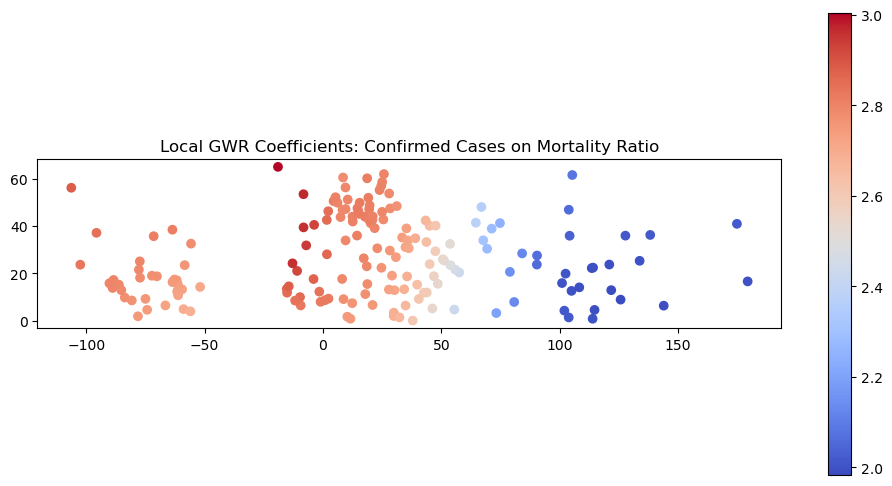

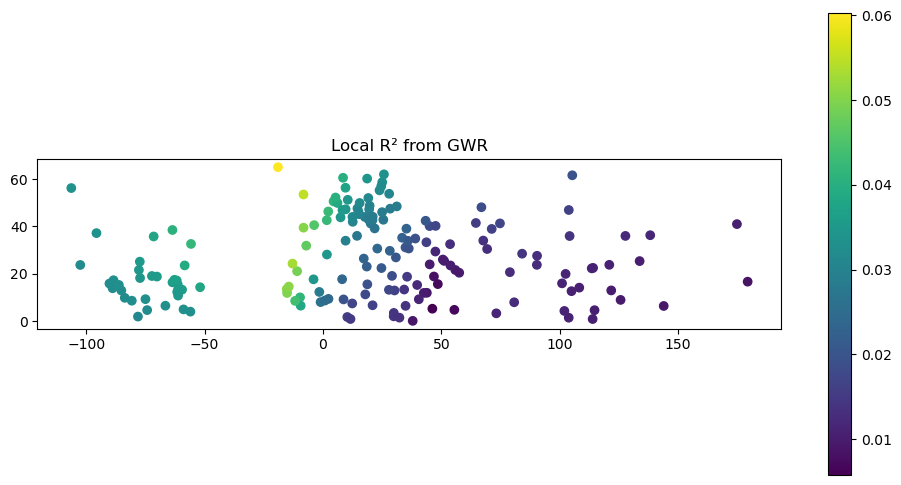

In [91]:
# 10. Add local coefficients to GeoDataFrame
gdf['Confirmed_coef'] = results.params[:,0]

# 11. Visualize local coefficients
gdf.plot(column='Confirmed_coef', cmap='coolwarm', legend=True, figsize=(12,6))
plt.title("Local GWR Coefficients: Confirmed Cases on Mortality Ratio")
plt.savefig('coefficient.jpeg')
plt.show()

# 12. Optional: visualize local R-squared
gdf['local_R2'] = results.localR2
gdf.plot(column='local_R2', cmap='viridis', legend=True, figsize=(12,6))
plt.title("Local R² from GWR")
plt.savefig('gwr.jpeg')
plt.show()


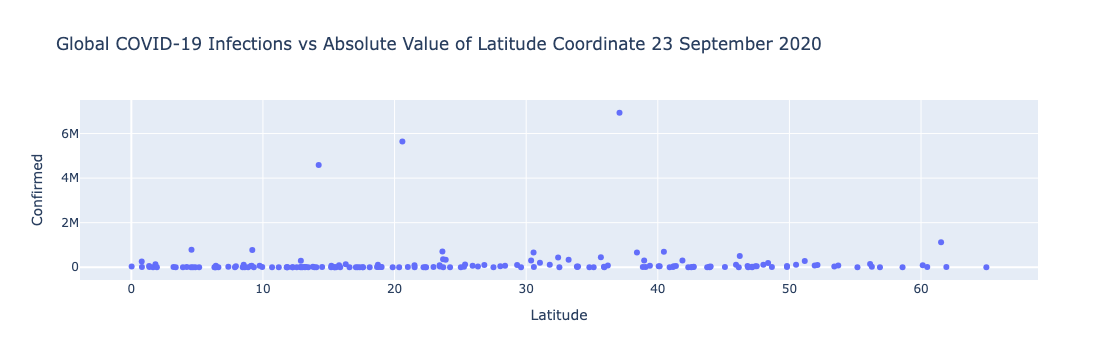

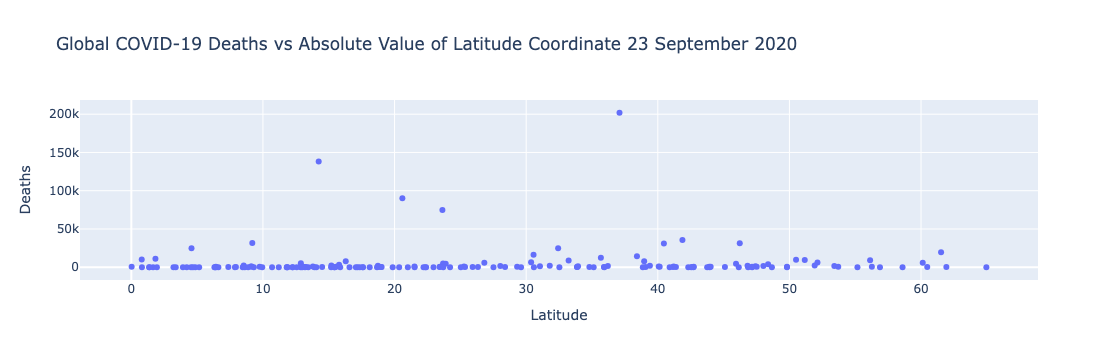

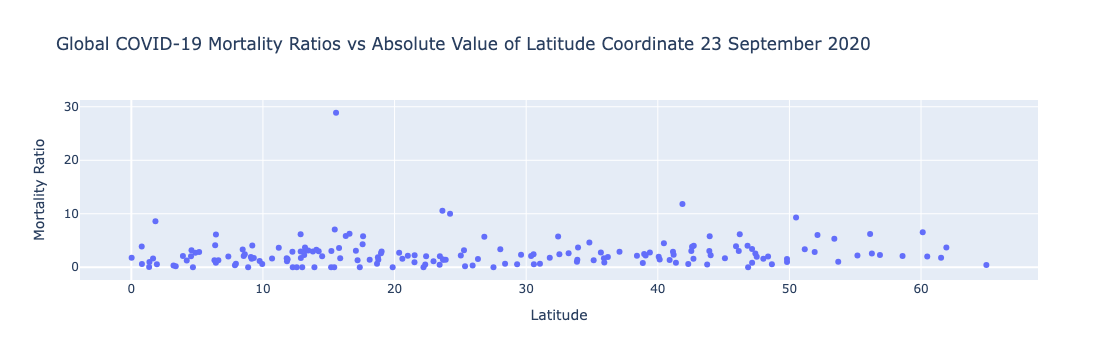

,Country,Confirmed,Deaths,Mortality Ratio,Latitude,Longitude,Country_Code
173,Yemen,2029.0,586.0,28.88,15.552727,48.516388,YE
78,Italy,302537.0,35758.0,11.82,41.871940,12.567380,IT
105,Mexico,710049.0,74949.0,10.56,23.634501,-102.552784,MX
172,Western Sahara,10.0,1.0,10.00,24.215527,-12.885834,EH
16,Belgium,106887.0,9959.0,9.32,50.503887,4.469936,BE
46,Ecuador,129892.0,11171.0,8.60,1.831239,-78.183406,EC
32,Chad,1164.0,82.0,7.04,15.454166,18.732207,TD
152,Sweden,89756.0,5876.0,6.55,60.128161,18.643501,SE
53,Fiji,32.0,2.0,6.25,16.578193,179.414413,FJ
30,Canada,149939.0,9294.0,6.20,56.130366,-106.346771,CA


In [67]:
dataset_global2 = dataset_global
dataset_global2['Latitude'] = abs(dataset_global2['Latitude'])
dataset_global2 = dataset_global2[dataset_global2['Country']!='China']

fig = px.scatter(dataset_global2.sort_values('Deaths',ascending=False), 
             x="Latitude", 
             y="Confirmed",
             title='Global COVID-19 Infections vs Absolute Value of Latitude Coordinate 23 September 2020')
fig.show()

fig = px.scatter(dataset_global2.sort_values('Deaths',ascending=False), 
             x="Latitude", 
             y="Deaths",
             title='Global COVID-19 Deaths vs Absolute Value of Latitude Coordinate 23 September 2020')
fig.show()
fig = px.scatter(dataset_global2.sort_values('Deaths',ascending=False), 
             x="Latitude", y="Mortality Ratio",
             title='Global COVID-19 Mortality Ratios vs Absolute Value of Latitude Coordinate 23 September 2020')
fig.show()
dataset_global.sort_values('Mortality Ratio', ascending= False).head(10)